In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy

import caustics
from caustics import Module, forward, Param
from caustics import utils

import sncosmo

from torch.nn.functional import conv2d, avg_pool2d
import torch
from torch import pi
from torch import where
from torch import Tensor

import h5py
import os
import pickle


mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

# 1. Flux stats

## 1.1 Flux residuals for diff separations

In [25]:
 #72358 #17462 #96679

# caustics_version =  '_04_03_26' #'_04_03_26'
# scarlet_date = '22_03_26'

oversamplefactor = 1
bands = ['lsstg', 'lsstr', 'lssti']
band_names = [r'$g$', r'$r$', r'$i$']
zero_points = [28.30, 28.13, 27.79]
all_fluxes = []
caustics_times = np.arange(0, 150, 2) 
sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]
sc_indices = [np.where(caustics_times == t)[0][0] for t in sc_times]
# print(sc_indices)


In [26]:
import pickle

### Fully belnded
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_62425_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_blended1 = pickle.load(sc_f)  #[band][epoch][image]
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_216276_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_rubin_blended2 = pickle.load(sc_f)  #[band][epoch][image]
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_209546_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_rubin_blended3 = pickle.load(sc_f)  #[band][epoch][image]

with open(f'fluxes_files/caustics_flux/caustics_fluxes_62425_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_blended1 = pickle.load(caustics_f)  #[band][epoch][image]
with open(f'fluxes_files/caustics_flux/caustics_fluxes_216276_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_blended2 = pickle.load(caustics_f)  #[band][epoch][image]
with open(f'fluxes_files/caustics_flux/caustics_fluxes_209546_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_blended3 = pickle.load(caustics_f)  #[band][epoch][image]

### Marginally
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_111827_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_marg1 = pickle.load(sc_f)  #[band][epoch][image]
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_64783_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_marg2 = pickle.load(sc_f)  #[band][epoch][image]
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_157804_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_marg3 = pickle.load(sc_f)  #[band][epoch][image]
# with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_96679_v14.pkl', "rb") as sc_f:
#     scarlet_fluxes_marg4 = pickle.load(sc_f)  #[band][epoch][image]


with open(f'fluxes_files/caustics_flux/caustics_fluxes_111827_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_marg1 = pickle.load(caustics_f)  #[band][epoch][image]
with open(f'fluxes_files/caustics_flux/caustics_fluxes_64783_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_marg2 = pickle.load(caustics_f)  #[band][epoch][image]
with open(f'fluxes_files/caustics_flux/caustics_fluxes_157804_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_marg3 = pickle.load(caustics_f)  #[band][epoch][image]
# with open(f'fluxes_files/caustics_flux/caustics_fluxes_96679_14_04_26.pkl', "rb") as caustics_f:
#     caustics_fluxes_marg4 = pickle.load(caustics_f)  #[band][epoch][image]


### Resolved
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_2737_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_resolved1 = pickle.load(sc_f)  #[band][epoch][image]
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_170330_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_resolved2 = pickle.load(sc_f)  #[band][epoch][image]
with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_50421_v6.pkl', "rb") as sc_f:
    scarlet_fluxes_resolved3 = pickle.load(sc_f)  #[band][epoch][image]


with open(f'fluxes_files/caustics_flux/caustics_fluxes_2737_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_resolved1 = pickle.load(caustics_f)  #[band][epoch][image]
with open(f'fluxes_files/caustics_flux/caustics_fluxes_170330_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_resolved2 = pickle.load(caustics_f)  #[band][epoch][image]
with open(f'fluxes_files/caustics_flux/caustics_fluxes_50421_14_04_26.pkl', "rb") as caustics_f:
    caustics_fluxes_resolved3 = pickle.load(caustics_f)  #[band][epoch][image]




/tmp/ipykernel_1768324/458256674.py:15: RuntimeWarning: divide by zero encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))
/tmp/ipykernel_1768324/458256674.py:15: RuntimeWarning: invalid value encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))
/tmp/ipykernel_1768324/458256674.py:18: RuntimeWarning: Mean of empty slice
  mean_bias = np.nanmean(all_biases, axis=0)


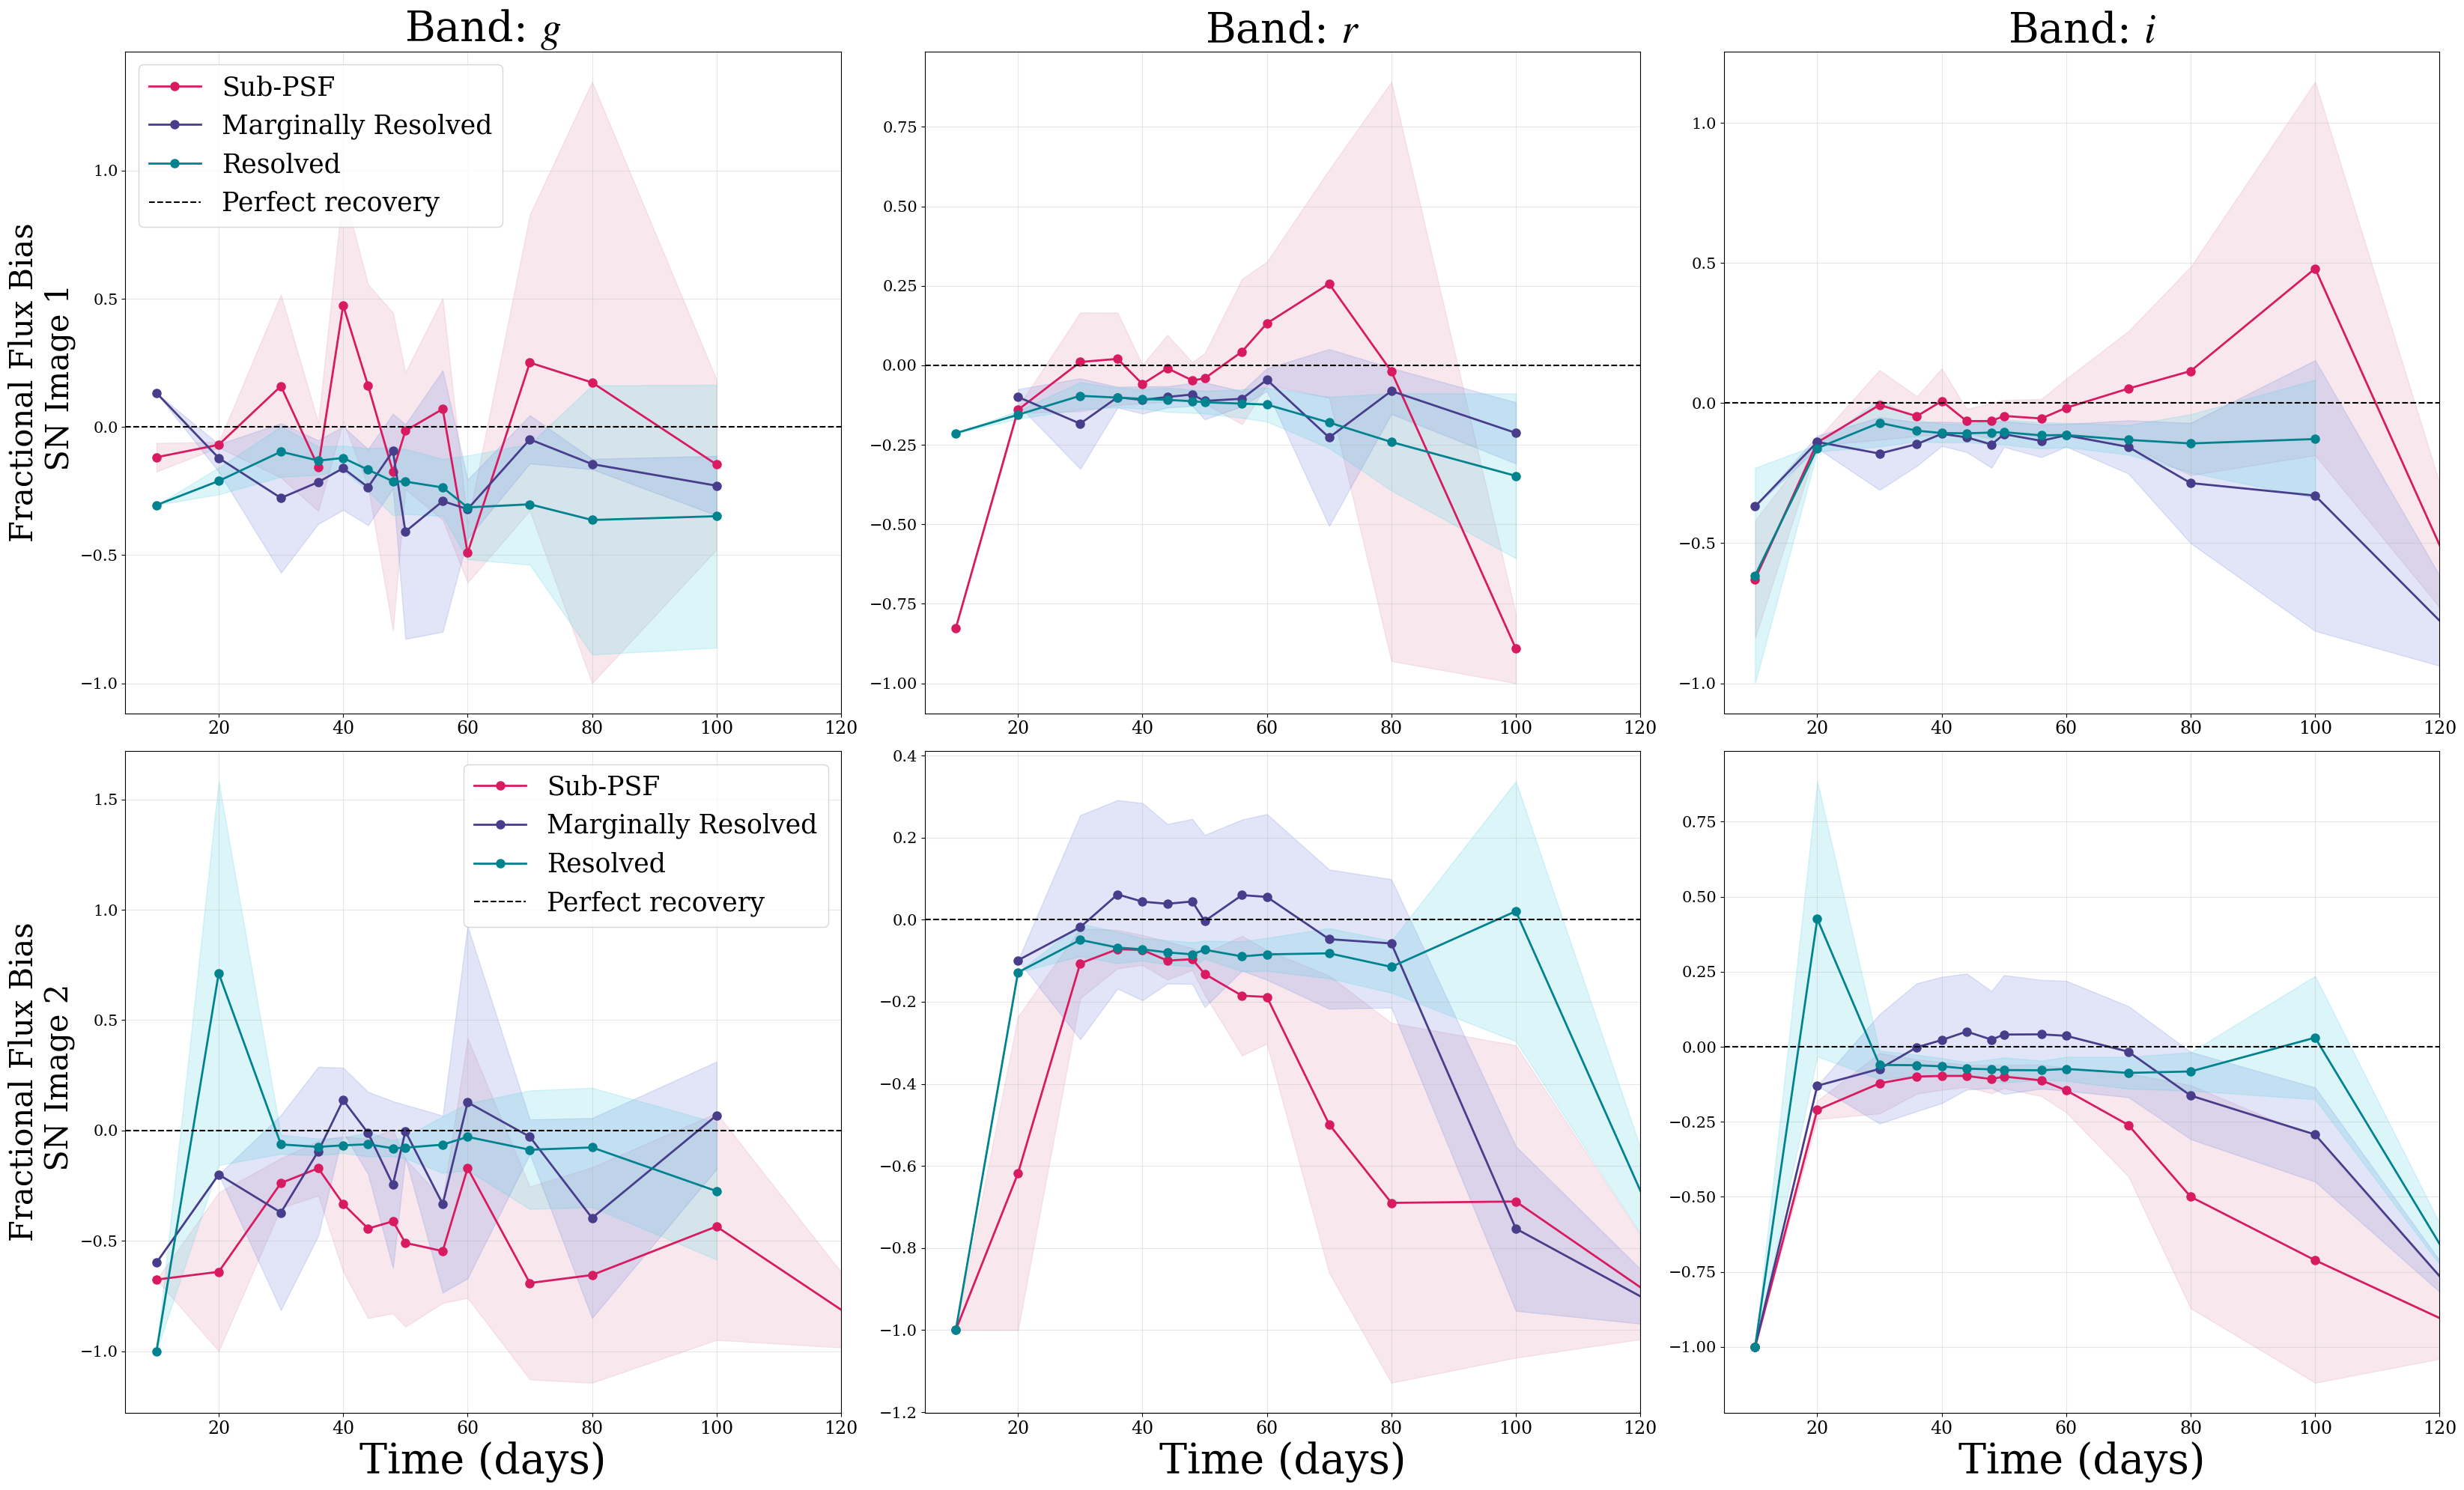

In [27]:
from scipy.stats import sem

def get_mean_std_bias(flux_list, caustics_flux_list, sc_indices, band_indx, img_indx, n_images, img_order_correct):
    """compute mean and std of fractional bias across multiple systems"""
    all_biases = []
    for sc_flux_all, caustics_flux_all, img_order in zip(flux_list, caustics_flux_list, img_order_correct):
        sc_flux       = np.array([sc_flux_all[band_indx][t][img_indx] for t in range(len(sc_flux_all[band_indx]))])
        if img_order:
            caustics_flux = np.array([caustics_flux_all[band_indx][t][img_indx] for t in sc_indices])
        else:
            caustics_flux = np.array([caustics_flux_all[band_indx][t][n_images - 1 - img_indx] for t in sc_indices])
            
        bias = np.where((caustics_flux == 0) & (sc_flux == 0), np.nan,
                        np.where(np.abs(caustics_flux) < 1, np.nan,
                                 (sc_flux - caustics_flux) / caustics_flux))
        all_biases.append(bias)
    all_biases = np.array(all_biases)
    mean_bias = np.nanmean(all_biases, axis=0)
    std_bias  = np.nanstd(all_biases, axis=0)
    return mean_bias, std_bias

# define your categories — you need matching caustics fluxes per system too!
categories = [
    {
        "label": "Sub-PSF",
        "color": "#D81B60",
        "color_fill": "#E08DAC",
        "sc_fluxes":       [scarlet_fluxes_blended1, scarlet_fluxes_rubin_blended2, scarlet_fluxes_rubin_blended3],
        "caustics_fluxes": [caustics_fluxes_blended1, caustics_fluxes_blended2, caustics_fluxes_blended3],
         "image_order": [False, False, True]
    },
    {
        "label": "Marginally Resolved",
        "color": "#483D8B",
        "color_fill": "#6A7FDB",
        "sc_fluxes":       [scarlet_fluxes_marg1, scarlet_fluxes_marg2, scarlet_fluxes_marg3],  #, scarlet_fluxes_marg4],  # was wrong before
        "caustics_fluxes": [caustics_fluxes_marg1, caustics_fluxes_marg2, caustics_fluxes_marg3], #, caustics_fluxes_marg4],
        "image_order": [False, False, True]
    },
    {
        "label": "Resolved",
        "color": "#00838F",  
        "color_fill": "#4DD0E1",
        "sc_fluxes":        [scarlet_fluxes_resolved1, scarlet_fluxes_resolved2, scarlet_fluxes_resolved3],
        "caustics_fluxes": [caustics_fluxes_resolved1, caustics_fluxes_resolved2, caustics_fluxes_resolved3],
        "image_order": [True, True, True]
    },
]

n_images = 2
fig, axes = plt.subplots(n_images, len(bands), figsize=(33, 20), sharey=False)

for band_indx in range(len(bands)):
    for img_indx in range(n_images):
        ax = axes[img_indx][band_indx]
        for cat in categories:
            mean_bias, std_bias = get_mean_std_bias(
                cat["sc_fluxes"], cat["caustics_fluxes"],
                sc_indices, band_indx, img_indx, n_images, 
                cat["image_order"])
            # print('Mean bias:', mean_bias)
            # print(std_bias)
            ax.plot(sc_times, mean_bias, marker='o', markersize=8,
                    color=cat["color"], label=cat["label"], linewidth=2.0)
            ax.fill_between(sc_times, mean_bias - std_bias, mean_bias + std_bias,
                            alpha=0.2, color=cat["color_fill"])
        ax.axhline(0, color='k', linestyle='--', label='Perfect recovery')
        ax.grid(alpha=0.3)
        axes[0][band_indx].set_title(f'Band: {band_names[band_indx]}', fontsize=40)
        axes[1][band_indx].set_xlabel('Time (days)', fontsize=40)

        axes[img_indx][band_indx].xaxis.set_tick_params(labelsize=17)
        axes[img_indx][band_indx].yaxis.set_tick_params(labelsize=15)

        axes[img_indx][band_indx].set_xlim(5, 120)
        
for img_indx in range(n_images):
    axes[img_indx][0].set_ylabel(f'Fractional Flux Bias\n SN Image {img_indx+1}', fontsize=30)
    # axes[img_indx][0].set_xlim(20, 100)
    # axes[img_indx][1].set_xlim(20, 100)
    # axes[img_indx][2].set_xlim(20, 100)

axes[0][0].legend(loc='upper left', fontsize=25)
axes[1][0].legend(loc='upper right', fontsize=25)


# fig.suptitle('Fractional Flux Bias by Blending Regime', fontsize=32)
plt.tight_layout()
# fig.savefig(f"thesis_plots/blending_limits_flux_res.png", bbox_inches='tight')
plt.show()

In [28]:
def get_rms_bias_categories(cat, sc_indices, n_images):
    all_biases = []
    for band_indx in range(len(bands)):
        for img_indx in range(n_images):
            for sc_flux_all, caustics_flux_all, img_order in zip(cat["sc_fluxes"], cat["caustics_fluxes"], cat["image_order"]):
                sc_flux       = np.array([sc_flux_all[band_indx][t][img_indx] for t in range(len(sc_flux_all[band_indx]))])
                caustics_indx = img_indx if img_order else n_images - 1 - img_indx
                caustics_flux = np.array([caustics_flux_all[band_indx][t][caustics_indx] for t in sc_indices])
                bias = np.where((caustics_flux == 0) & (sc_flux == 0), np.nan,
                                np.where(np.abs(caustics_flux) < 1, np.nan,
                                         (sc_flux - caustics_flux) / caustics_flux))
                all_biases.extend(bias[~np.isnan(bias)])
    all_biases = np.array(all_biases)
    rms  = np.sqrt(np.mean(all_biases**2))
    mean = np.mean(np.abs(all_biases))
    std  = np.std(all_biases)
    return rms, mean, std

# print table
col_width = 30
header = f"{'Category':<25}" + f"{'RMS':>{col_width}}" + f"{'Mean':>{col_width}}" + f"{'Std':>{col_width}}"
print(header)
print("-" * (25 + col_width * 3))
for cat in categories:
    rms, mean, std = get_rms_bias_categories(cat, sc_indices, n_images=2)
    print(f"{cat['label']:<25}{rms:>{col_width}.4f}{mean:>{col_width}.4f}{std:>{col_width}.4f}")

Category                                            RMS                          Mean                           Std
-------------------------------------------------------------------------------------------------------------------
Sub-PSF                                          0.4873                        0.3346                        0.4434
Marginally Resolved                              0.3295                        0.2248                        0.3002
Resolved                                         0.3026                        0.1901                        0.2689


/tmp/ipykernel_1768324/624747874.py:11: RuntimeWarning: divide by zero encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))
/tmp/ipykernel_1768324/624747874.py:11: RuntimeWarning: invalid value encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))


## 1.2 Roman off/No Roman flux comparison

In [7]:

scarlet_date = '22_03_26'
oversamplefactor = 1
bands = ['lsstg', 'lsstr', 'lssti']
band_names = [r'$g$', r'$r$', r'$i$']
zero_points = [28.30, 28.13, 27.79]
caustics_times = np.arange(0, 150, 2) 
sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]
sc_indices = [np.where(caustics_times == t)[0][0] for t in sc_times]
# print(sc_indices)


/tmp/ipykernel_3928385/2745969053.py:76: RuntimeWarning: divide by zero encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))
/tmp/ipykernel_3928385/2745969053.py:76: RuntimeWarning: invalid value encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))
/tmp/ipykernel_3928385/2745969053.py:80: RuntimeWarning: Mean of empty slice
  return np.nanmean(all_biases, axis=0), np.nanstd(all_biases, axis=0)
/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


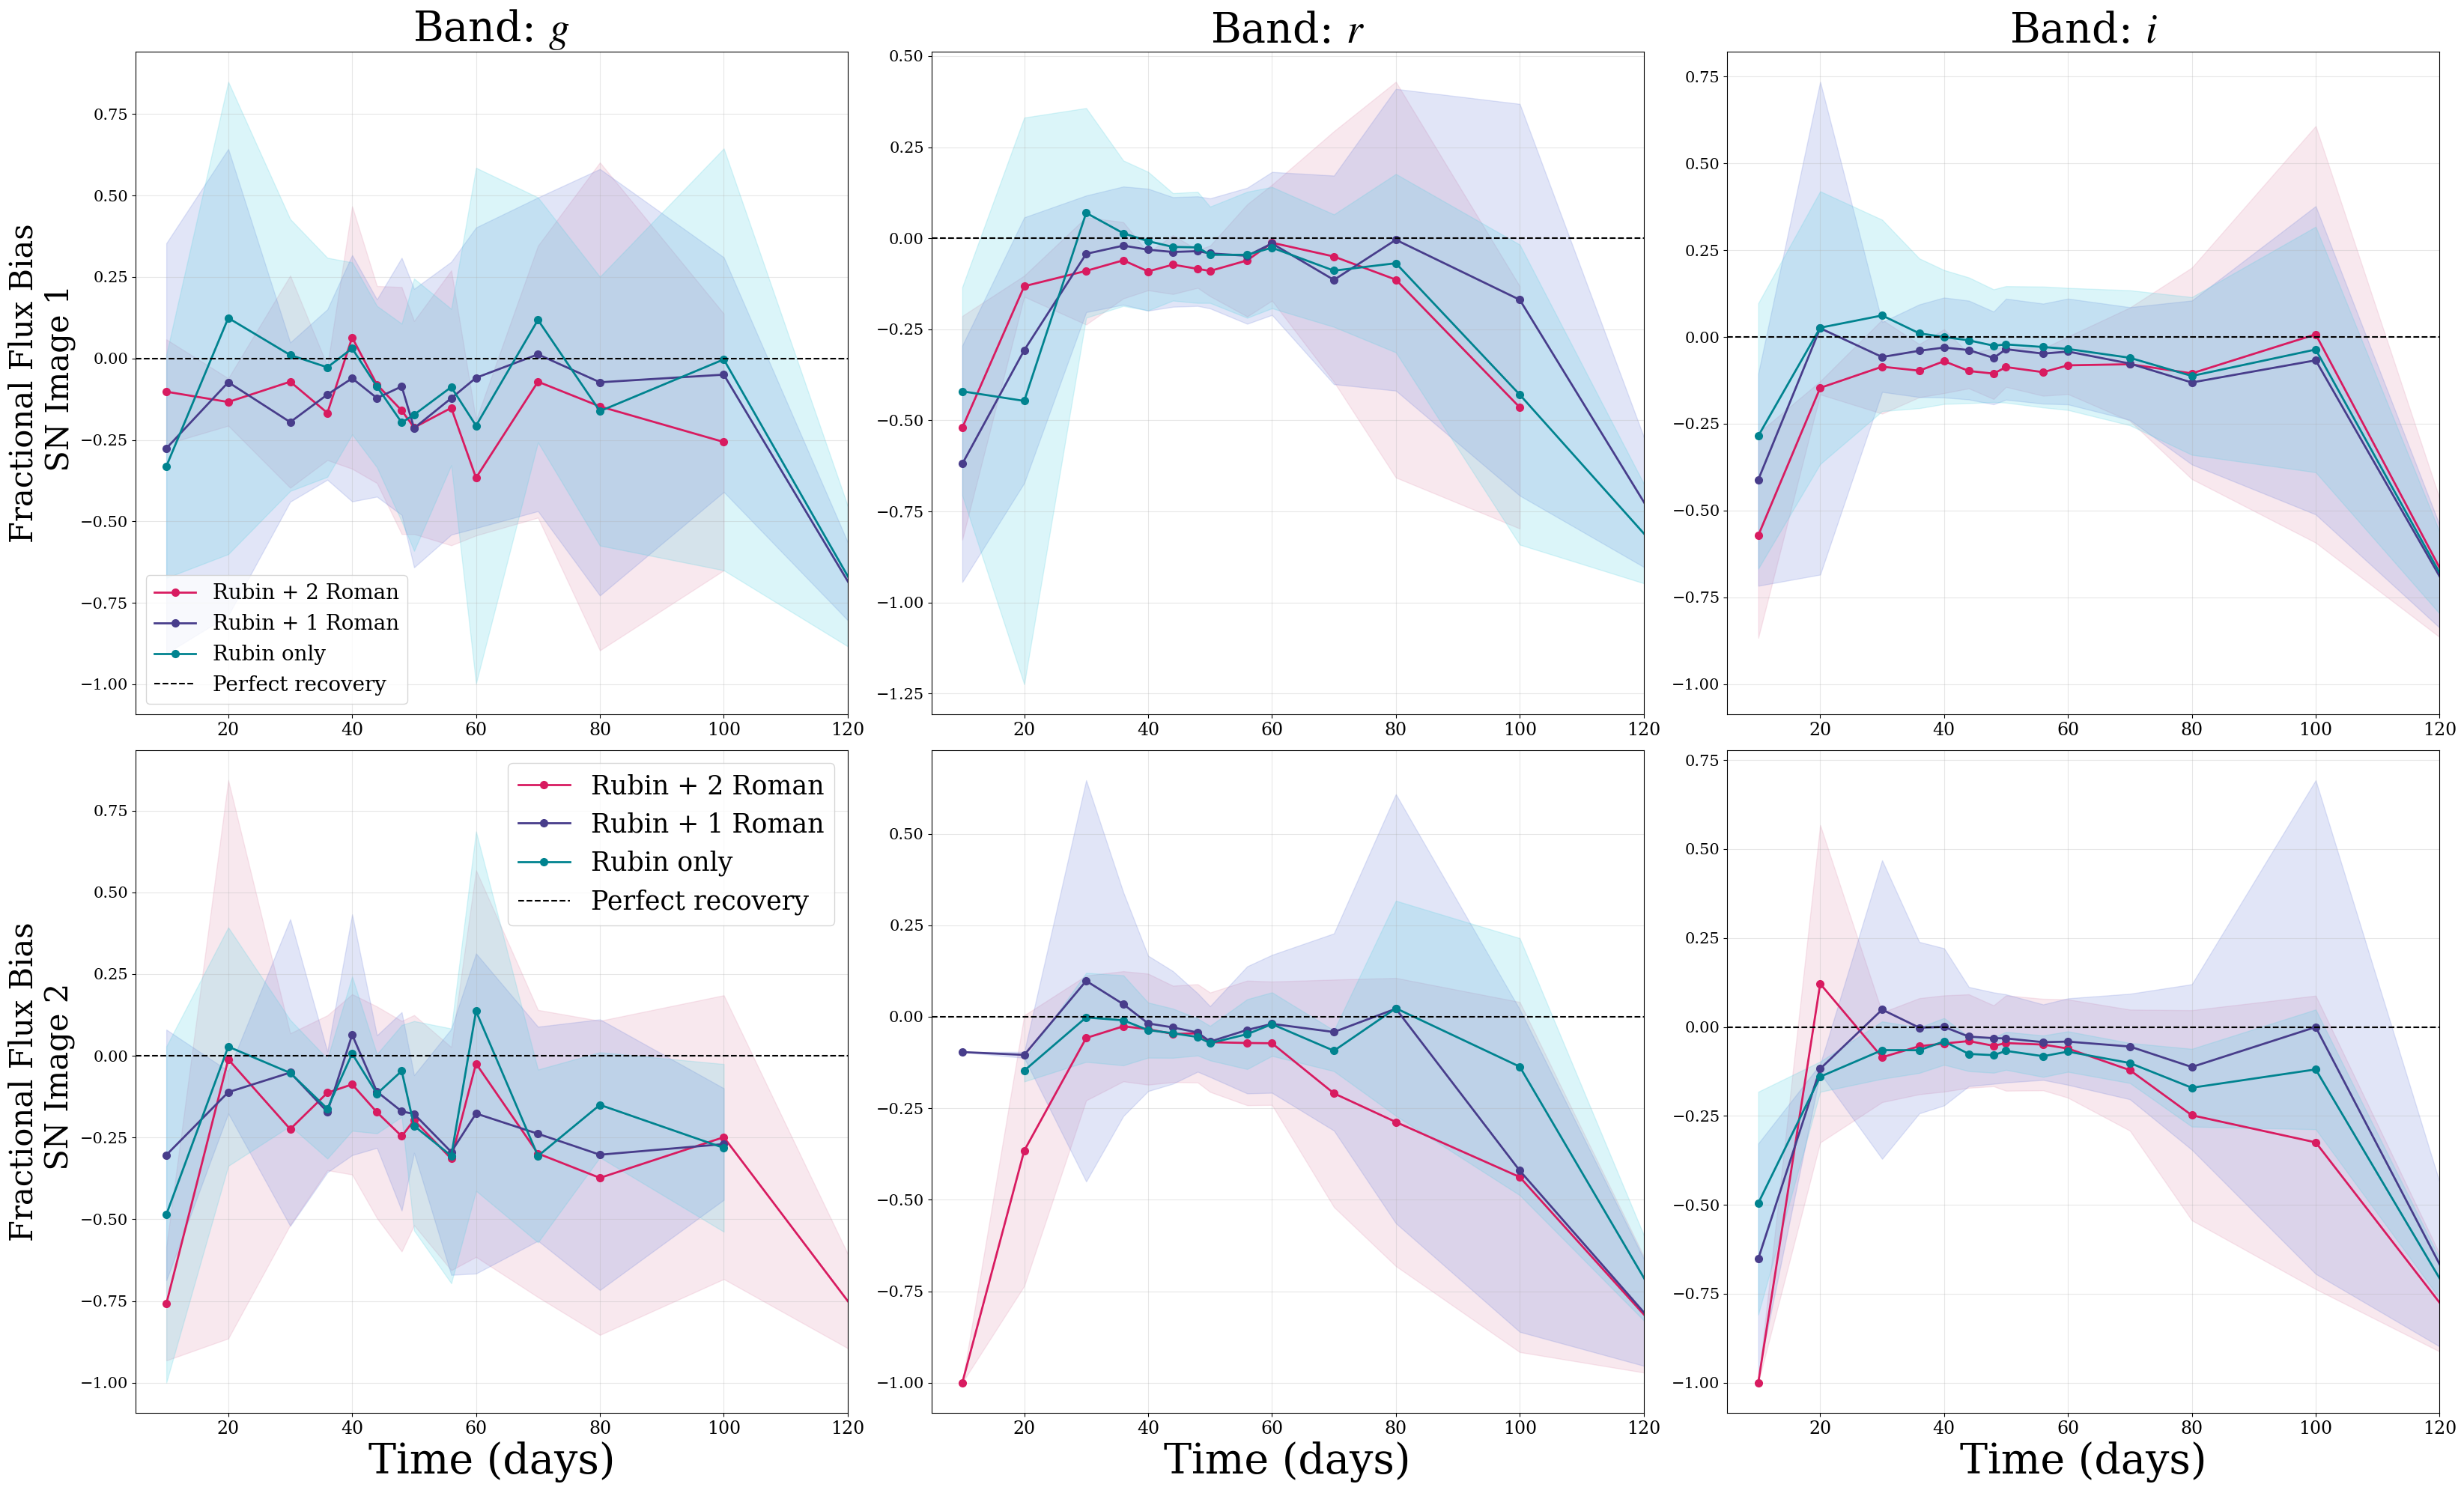

In [8]:
systems = [
    # Blended
    {"id": 62425,  "caustics_version": "14_04_26", 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": True, "Rubin + 1 Roman": True,  "Rubin + 2 Roman": False}},
    ##
    {"id": 216276, "caustics_version": "14_04_26",
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": False, "Rubin + 1 Roman": False, "Rubin + 2 Roman": False}},
    ##
    {"id": 209546, "caustics_version": "14_04_26",
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": False, "Rubin + 1 Roman": False,  "Rubin + 2 Roman": True}},
    
    # Marginally blended
    # {"id": 96679,  "caustics_version": "04_03_26",
    #  "sc_versions": {"Rubin only": "v2", "Rubin + 1 Roman": "v3", "Rubin + 2 Roman": "v14"},
    #  "img_order":   {"Rubin only": False, "Rubin + 1 Roman": False, "Rubin + 2 Roman": False}},
    
    ##
    {"id": 111827, "caustics_version": "14_04_26",
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": True, "Rubin + 1 Roman": False, "Rubin + 2 Roman": False}},
    ##
    {"id": 64783,  "caustics_version": "14_04_26",
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": True, "Rubin + 1 Roman": True, "Rubin + 2 Roman": False}},
    ##
    {"id": 157804, "caustics_version": "14_04_26",
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": False, "Rubin + 1 Roman": True,  "Rubin + 2 Roman": True}},
    
    # Resolved
    {"id": 2737,   "caustics_version": "14_04_26", 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": False, "Rubin + 1 Roman": False, "Rubin + 2 Roman": True}},
    # ##
    {"id": 170330, "caustics_version": "14_04_26", 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": True, "Rubin + 1 Roman": False, "Rubin + 2 Roman": True}},
    ##
    {"id": 50421,  "caustics_version": "14_04_26",
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"},
     "img_order":   {"Rubin only": True, "Rubin + 1 Roman": False, "Rubin + 2 Roman": True}}
]

scenarios = [
    {"label": "Rubin + 2 Roman", "colors": ["#D81B60", "#D81B60"], "fill_colors":["#E08DAC", "#E08DAC"]},    # ["#001044", "#5D001E"]
     {"label": "Rubin + 1 Roman", "colors": ["#483D8B", "#483D8B"], "fill_colors":["#6A7FDB", "#6A7FDB"]},   # ["#2962FF", "#D32F2F"]
    {"label": "Rubin only",      "colors": ["#00838F", "#00838F"], "fill_colors":["#4DD0E1", "#4DD0E1"]}     # ["#02d8e9", "#F06292"]
]

# load all fluxes upfront
for sys in systems:
    sid = sys["id"]
    with open(f'fluxes_files/caustics_flux/caustics_fluxes_{sid}_{sys["caustics_version"]}.pkl', "rb") as f:
        sys["caustics_fluxes"] = pickle.load(f)
    sys["sc_fluxes"] = {}
    for label, version in sys["sc_versions"].items():
        with open(f'fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_{sid}_{version}.pkl', "rb") as f:
            sys["sc_fluxes"][label] = pickle.load(f)

def get_mean_std_bias_systems(systems, scenario_label, sc_indices, band_indx, img_indx, n_images):
    all_biases = []
    for sys in systems:
        sc_flux_all       = sys["sc_fluxes"][scenario_label]
        caustics_flux_all = sys["caustics_fluxes"]
        img_order         = sys["img_order"][scenario_label]  # now per-scenario
        
        sc_flux       = np.array([sc_flux_all[band_indx][t][img_indx] for t in range(len(sc_flux_all[band_indx]))])
        caustics_indx = img_indx if img_order else n_images - 1 - img_indx
        caustics_flux = np.array([caustics_flux_all[band_indx][t][caustics_indx] for t in sc_indices])
        
        bias = np.where((caustics_flux == 0) & (sc_flux == 0), np.nan,
                        np.where(np.abs(caustics_flux) < 1, np.nan,
                                 (sc_flux - caustics_flux) / caustics_flux))
        all_biases.append(bias)
    
    all_biases = np.array(all_biases)
    return np.nanmean(all_biases, axis=0), np.nanstd(all_biases, axis=0)

# plot — rest stays the same
n_images = 2
fig, axes = plt.subplots(n_images, len(bands), figsize=(33, 20), sharey=False)

for band_indx in range(len(bands)):
    for img_indx in range(n_images):
        ax = axes[img_indx][band_indx]
        for scenario in scenarios:
            mean_bias, std_bias = get_mean_std_bias_systems(
                systems, scenario["label"], sc_indices, band_indx, img_indx, n_images
            )
            ax.plot(sc_times, mean_bias, marker='o', markersize=7,
                    color=scenario["colors"][img_indx],
                    label=scenario["label"], linewidth=2.0)
            ax.fill_between(sc_times, mean_bias - std_bias, mean_bias + std_bias,
                            alpha=0.2, color=scenario["fill_colors"][img_indx])
            # print(mean_bias)
            # print(std_bias)
        ax.axhline(0, color='k', linestyle='--', label='Perfect recovery')
        ax.grid(alpha=0.3)
        axes[0][band_indx].set_title(f'Band: {band_names[band_indx]}', fontsize=40)
        axes[1][band_indx].set_xlabel('Time (days)', fontsize=40)
        axes[img_indx][band_indx].xaxis.set_tick_params(labelsize=17)
        axes[img_indx][band_indx].yaxis.set_tick_params(labelsize=15)

        axes[img_indx][band_indx].set_xlim(5, 120)
        # axes[img_indx][band_indx].set_ylim(-1, 1)

for img_indx in range(n_images):
    axes[img_indx][0].set_ylabel(f'Fractional Flux Bias\n SN Image {img_indx+1}', fontsize=30)

axes[0][0].legend(loc='lower left', fontsize=20)
axes[1][0].legend(loc='upper right', fontsize=25)
plt.tight_layout()
# fig.savefig(f"thesis_plots/follow_up_comparisons.png", bbox_inches='tight')
plt.show()

In [10]:
from itertools import product

blending_groups = {
    "Blended":            [s for s in systems if s["id"] in [62425, 216276, 209546]],
    "Marginally Blended": [s for s in systems if s["id"] in [111827, 64783, 157804]],
    "Resolved":         [s for s in systems if s["id"] in [2737, 170330, 50421]],
}

scenario_labels = ["Rubin only", "Rubin + 1 Roman", "Rubin + 2 Roman"]

# compute RMS bias for a given set of systems and scenario
def get_rms_bias(systems_subset, scenario_label, sc_indices, n_images):
    all_biases = []
    for band_indx in range(len(bands)):
        for img_indx in range(n_images):
            for sys in systems_subset:
                sc_flux_all       = sys["sc_fluxes"][scenario_label]
                caustics_flux_all = sys["caustics_fluxes"]
                img_order         = sys["img_order"][scenario_label]

                sc_flux       = np.array([sc_flux_all[band_indx][t][img_indx] for t in range(len(sc_flux_all[band_indx]))])
                caustics_indx = img_indx if img_order else n_images - 1 - img_indx
                caustics_flux = np.array([caustics_flux_all[band_indx][t][caustics_indx] for t in sc_indices])

                bias = np.where((caustics_flux == 0) & (sc_flux == 0), np.nan,
                                np.where(np.abs(caustics_flux) < 1, np.nan,
                                         (sc_flux - caustics_flux) / caustics_flux))
                all_biases.extend(bias[~np.isnan(bias)])

    all_biases = np.array(all_biases)
    rms  = np.sqrt(np.mean(all_biases**2))
    mean = np.mean(np.abs(all_biases))
    std  = np.std(all_biases)
    return rms, mean, std

# print table
header = f"{'Scenario':<20}" + "".join([f"{g:>25}" for g in blending_groups.keys()])
print(header)
print("-" * (20 + 25 * len(blending_groups)))

for scenario_label in scenario_labels:
    row = f"{scenario_label:<20}"
    for group_name, group_systems in blending_groups.items():
        rms, mean, std = get_rms_bias(group_systems, scenario_label, sc_indices, n_images=2)
        row += f"  RMS={rms:.3f} μ={mean:.3f} σ={std:.3f}"
    print(row)

Scenario                              Blended       Marginally Blended                 Resolved
-----------------------------------------------------------------------------------------------
Rubin only            RMS=0.438 μ=0.278 σ=0.401  RMS=0.362 μ=0.250 σ=0.361  RMS=0.190 μ=0.112 σ=0.159
Rubin + 1 Roman       RMS=0.510 μ=0.357 σ=0.491  RMS=0.335 μ=0.215 σ=0.319  RMS=0.239 μ=0.126 σ=0.226
Rubin + 2 Roman       RMS=0.487 μ=0.335 σ=0.443  RMS=0.330 μ=0.225 σ=0.300  RMS=0.303 μ=0.190 σ=0.269


/tmp/ipykernel_3928385/1465155065.py:27: RuntimeWarning: invalid value encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))
/tmp/ipykernel_3928385/1465155065.py:27: RuntimeWarning: divide by zero encountered in divide
  (sc_flux - caustics_flux) / caustics_flux))


# 2. Time Delay Stats

## 2.1 GausSN

In [25]:
true_delays = np.array([13.61, 13.51, 10.87, 9.37, 9.89, 12.99, 11.51, 14.15, 8.16])

scenarios = {
    "off & on Roman": np.array([21.86, 12.88, 11.01, 12.57, 11.03, 13.61, 11.75, 14.36, 8.29]),
    "off Roman only": np.array([16.94, 12.83, 10.74, 11.55, 10.87, 14.48, 11.54, 14.40, 8.19]),
    "no Roman":       np.array([12.14, 12.60, 9.75, 9.03, 9.33, 11.64, 11.45, 13.98, 8.18]),
}

uncertainties = {
    "off & on Roman": {
        "upper": np.array([0.49, 0.05, 0.03, 0.04, 0.06, 0.03, 0.03, 0.03, 0.03]),
        "lower": np.array([0.17, 0.05, 0.03, 0.04, 0.07, 0.03, 0.03, 0.03, 0.03]),
    },
    "off Roman only": {
        "upper": np.array([0.05, 0.05, 0.03, 0.04, 0.08, 0.04, 0.01, 0.03, 0.02]),
        "lower": np.array([0.05, 0.05, 0.03, 0.03, 0.08, 0.03, 0.01, 0.03, 0.02]),
    },
    "no Roman": {
        "upper": np.array([0.36, 0.17, 0.09, 0.27, 0.18, 0.30, 0.05, 0.09, 0.07]),
        "lower": np.array([0.34, 0.18, 0.09, 3.26, 0.19, 0.34, 0.05, 0.10, 0.07]),
    },
}


blending_groups = {
    "Blended":            slice(0, 3),   # systems 62425, 216276, 209546
    "Marginally Blended": slice(3, 6),   # systems 111827, 64783, 157804
    "Resolved":           slice(6, 9),   # systems 2737, 170330, 50421
}


def within_1sigma(pred, true, upper, lower):
    """check if true value falls within 1sigma of prediction"""
    return (true >= pred - lower) & (true <= pred + upper)

In [26]:
scenario = "off & on Roman"
preds = scenarios[scenario]
unc = uncertainties[scenario]
print("=" * 60)
print("Blendedness performance — off & on Roman only")
print("=" * 60)
print(f"{'Regime':<25} {'RMS':>8} {'μ (days)':>12} {'Frac%':>8} {'Within 1σ':>12}")
print("-" * 68)
for group_name, slc in blending_groups.items():
    signed_err = preds[slc] - true_delays[slc]
    abs_err  = np.abs(preds[slc] - true_delays[slc])
    frac_err = abs_err / true_delays[slc]
    rms        = np.sqrt(np.mean(signed_err**2))
    within     = within_1sigma(preds[slc], true_delays[slc], unc["upper"][slc], unc["lower"][slc])
    print(f"{group_name:<25} {rms:>8.2f} {np.mean(abs_err):>12.2f} {np.mean(frac_err)*100:>8.1f} {np.sum(within):>5}/{len(within)}")




Blendedness performance — off & on Roman only
Regime                         RMS     μ (days)    Frac%    Within 1σ
--------------------------------------------------------------------
Blended                       4.78         3.01     22.2     0/3
Marginally Blended            1.99         1.65     16.8     0/3
Resolved                      0.20         0.19      1.7     0/3


In [27]:
col_width = 45
header = f"{'Scenario':<20}" + "".join([f"{g:>{col_width}}" for g in blending_groups.keys()])
print(header)
print("-" * (20 + col_width * len(blending_groups)))

for scenario, preds in scenarios.items():
    row = f"{scenario:<20}"
    for group_name, slc in blending_groups.items():
        signed_err = preds[slc] - true_delays[slc]
        abs_err    = np.abs(signed_err)
        frac_err   = abs_err / true_delays[slc]
        rms        = np.sqrt(np.mean(signed_err**2))
        row += f"  RMS={rms:.2f} MAE={np.mean(abs_err):.2f} μ={np.mean(signed_err):.2f} |Frac|={np.mean(frac_err)*100:.1f}%"
    print(row)

Scenario                                                  Blended                           Marginally Blended                                     Resolved
-----------------------------------------------------------------------------------------------------------------------------------------------------------
off & on Roman        RMS=4.78 MAE=3.01 μ=2.59 |Frac|=22.2%  RMS=1.99 MAE=1.65 μ=1.65 |Frac|=16.8%  RMS=0.20 MAE=0.19 μ=0.19 |Frac|=1.7%
off Roman only        RMS=1.96 MAE=1.38 μ=0.84 |Frac|=10.2%  RMS=1.63 MAE=1.55 μ=1.55 |Frac|=14.9%  RMS=0.15 MAE=0.10 μ=0.10 |Frac|=0.8%
no Roman              RMS=1.19 MAE=1.17 μ=-1.17 |Frac|=9.3%  RMS=0.87 MAE=0.75 μ=-0.75 |Frac|=6.6%  RMS=0.10 MAE=0.08 μ=-0.07 |Frac|=0.7%


In [28]:

print("=" * 60)
print("a) Performance by number of Roman epochs")
print("=" * 60)
for scenario, preds in scenarios.items():
    unc = uncertainties[scenario]
    abs_err  = np.abs(preds - true_delays)
    frac_err = abs_err / true_delays
    within   = within_1sigma(preds, true_delays, unc["upper"], unc["lower"])
    signed_err = preds - true_delays  # positive = overestimate, negative = underestimate
    rms = np.sqrt(np.mean((preds - true_delays)**2))
    
    print(f"\n{scenario}:")
    print(f"  RMS error:      {rms:.2f} days")
    print(f"  Mean error (μ): {np.mean(abs_err):.2f} days")
    print(f"  Mean frac error:{np.mean(frac_err)*100:.1f}%")
    print(f"  Within 1sigma:  {np.sum(within)}/{len(within)} systems")



print("=" * 60)
print("b) Blendedness performance — all follow-up scenarios")
print("=" * 60)
print(f"{'Regime':<25} {'RMS':>8} {'μ (days)':>12} {'Frac%':>8} {'Within 1σ':>12}")
print("-" * 68)
for group_name, slc in blending_groups.items():
    all_signed = []
    all_within = []
    for scenario, preds in scenarios.items():
        unc = uncertainties[scenario]
        signed_err = preds[slc] - true_delays[slc]
        abs_err    = np.abs(signed_err)
        all_signed.extend(signed_err)
        all_within.extend(within_1sigma(preds[slc], true_delays[slc], unc["upper"][slc], unc["lower"][slc]))
    all_signed = np.array(all_signed)
    rms      = np.sqrt(np.mean(all_signed**2))
    frac_err = np.abs(all_signed) / np.tile(true_delays[slc], len(scenarios))
    print(f"{group_name:<25} {rms:>8.2f} {np.mean(abs_err):>12.2f} {np.mean(frac_err)*100:>8.1f} {np.sum(all_within):>5}/{len(all_within)}")

a) Performance by number of Roman epochs

off & on Roman:
  RMS error:      2.99 days
  Mean error (μ): 1.62 days
  Mean frac error:13.6%
  Within 1sigma:  0/9 systems

off Roman only:
  RMS error:      1.47 days
  Mean error (μ): 1.01 days
  Mean frac error:8.6%
  Within 1sigma:  0/9 systems

no Roman:
  RMS error:      0.85 days
  Mean error (μ): 0.67 days
  Mean frac error:5.5%
  Within 1sigma:  1/9 systems
b) Blendedness performance — all follow-up scenarios
Regime                         RMS     μ (days)    Frac%    Within 1σ
--------------------------------------------------------------------
Blended                       3.06         1.17     13.9     0/9
Marginally Blended            1.57         0.75     12.8     0/9
Resolved                      0.15         0.08      1.1     1/9


In [29]:
# ── c) Overall statistics across all systems and scenarios ────────────────
print("\n" + "=" * 60)
print("c) Overall statistics")
print("=" * 60)

all_abs_err  = []
all_signed   = [] # To calculate Mean Signed Error and RMS
all_frac_err = []
all_within   = []

for scenario, preds in scenarios.items():
    unc = uncertainties[scenario]
    diff = preds - true_delays
    
    all_abs_err.extend(np.abs(diff))
    all_signed.extend(diff)
    all_frac_err.extend(np.abs(diff) / true_delays)
    all_within.extend(within_1sigma(preds, true_delays, unc["upper"], unc["lower"]))

# Convert to arrays for statistical calculation
all_signed = np.array(all_signed)
rmse = np.sqrt(np.mean(all_signed**2))
mean_signed_err = np.mean(all_signed)

print(f"  Mean absolute error (all):    {np.mean(all_abs_err):.2f} days")
print(f"  Median absolute error (all):  {np.median(all_abs_err):.2f} days")
print(f"  RMSE (all):                   {rmse:.2f} days")
print(f"  Mean signed error (Bias):     {mean_signed_err:.2f} days")
print(f"  Mean fractional error (all):  {np.mean(all_frac_err)*100:.1f}%")
print(f"  Within 1sigma (all):          {np.sum(all_within)}/{len(all_within)} ({100*np.mean(all_within):.0f}%)")


c) Overall statistics
  Mean absolute error (all):    1.10 days
  Median absolute error (all):  0.62 days
  RMSE (all):                   1.99 days
  Mean signed error (Bias):     0.55 days
  Mean fractional error (all):  9.2%
  Within 1sigma (all):          1/27 (4%)


# 2.2 Glimpse blended

In [30]:
true_delays_glimpse = np.array([13.61, 13.51, 10.87, 9.37, 9.89, 12.99, 11.51, 14.15, 8.16])

scenarios_glimpse_blended = {
    "off & on Roman": np.array([10.62, 11.28, 11.51, 9.40, 10.67, 11.98, 10.95, 9.03, 7.91]),
    "off Roman only": np.array([9.90, 13.41, 11.47, 9.12, 10.96, 10.62, 14.15, 8.20, 7.75]),
    "no Roman":       np.array([9.91, 12.35, 10.81, 6.68, 11.12, 13.28, 12.45, 13.48, 5.50]),
}

uncertainties_glimpse_blended = {
    "off & on Roman": {
        "upper": np.array([2.03, 1.03, 0.61, 1.95, 1.54, 1.24, 0.61, 3.24, 2.38]),
        "lower": np.array([1.86, 1.03, 0.66, 1.78, 1.42, 2.71, 0.65, 0.05, 0.38]),
    },
    "off Roman only": {
        "upper": np.array([3.24, 6.23, 0.81, 2.00, 1.49, 1.52, 0.54, 3.01, 0.82]),
        "lower": np.array([1.85, 4.73, 0.85, 1.63, 0.99, 1.93, 1.79, 2.80, 0.24]),
    },
    "no Roman": {
        "upper": np.array([3.63, 1.05, 0.52, 2.55, 0.86, 1.89, 3.11, 0.60, 0.80]),
        "lower": np.array([3.34, 1.29, 0.57, 2.85, 0.94, 1.64, 1.26, 0.84, 0.82]),
    },
}


blending_groups = {
    "Blended":            slice(0, 3),   # systems 62425, 216276, 209546
    "Marginally Blended": slice(3, 6),   # systems 111827, 64783, 157804
    "Resolved":           slice(6, 9),   # systems 2737, 170330, 50421
}


# a) by follow-up scenario
print("=" * 65)
print("a) Performance by Roman follow-up scenario")
print("=" * 65)
print(f"{'Scenario':<20} {'RMS':>8} {'μ (days)':>12} {'|Frac|%':>8} {'Within 1σ':>12}")
print("-" * 65)
for scenario, preds in scenarios_glimpse_blended.items():
    unc        = uncertainties_glimpse_blended[scenario]
    signed_err = preds - true_delays_glimpse
    abs_frac   = np.abs(signed_err) / true_delays_glimpse
    rms        = np.sqrt(np.mean(signed_err**2))
    within     = within_1sigma(preds, true_delays_glimpse, unc["upper"], unc["lower"])
    print(f"{scenario:<20} {rms:>8.2f} {np.mean(signed_err):>12.2f} {np.mean(abs_frac)*100:>8.1f} {np.sum(within):>5}/{len(within)}")

# b) by blending regime (collapsed across scenarios)
print("\n" + "=" * 65)
print("b) Performance by blending regime (all follow-up scenarios)")
print("=" * 65)
print(f"{'Regime':<25} {'RMS':>8} {'μ (days)':>12} {'|Frac|%':>8} {'Within 1σ':>12}")
print("-" * 65)
for group_name, slc in blending_groups.items():
    all_signed = []
    all_within = []
    all_fracs = [] # Add this to collect fractional errors individually
    
    # Get the true delays for this specific regime once
    true_regime = true_delays_glimpse[slc]
    
    for scenario, preds in scenarios_glimpse_blended.items():
        unc = uncertainties_glimpse_blended[scenario]
        
        # Calculate for this slice
        diff = preds[slc] - true_regime
        
        all_signed.extend(diff)
        all_within.extend(within_1sigma(preds[slc], true_regime, unc["upper"][slc], unc["lower"][slc]))
        
        # Calculate fractional error here to ensure it aligns perfectly
        all_fracs.extend(np.abs(diff) / true_regime)
    
    all_signed = np.array(all_signed)
    rms = np.sqrt(np.mean(all_signed**2))
    
    print(f"{group_name:<25} {rms:>8.2f} {np.mean(all_signed):>12.2f} {np.mean(all_fracs)*100:>8.1f} {np.sum(all_within):>5}/{len(all_within)}")



# ── c) Overall statistics for GLIMPSE (across all systems and scenarios) ──
print("\n" + "=" * 60)
print("c) Overall statistics (all systems & scenarios)")
print("=" * 60)

# Pool everything into flat arrays (size = 27)
all_diffs = []
all_abs_fracs = []
all_within = []

for scenario, preds in scenarios_glimpse_blended.items():
    unc = uncertainties_glimpse_blended[scenario]
    diff = preds - true_delays_glimpse
    
    all_diffs.extend(diff)
    all_abs_fracs.extend(np.abs(diff) / true_delays_glimpse)
    all_within.extend(within_1sigma(preds, true_delays_glimpse, unc["upper"], unc["lower"]))

# Calculate final stats
all_diffs = np.array(all_diffs)
all_abs_err = np.abs(all_diffs)

rmse = np.sqrt(np.mean(all_diffs**2))
mean_signed_err = np.mean(all_diffs)

print(f"  Mean absolute error (all):    {np.mean(all_abs_err):.2f} days")
print(f"  Median absolute error (all):  {np.median(all_abs_err):.2f} days")
print(f"  RMSE (all):                   {rmse:.2f} days")
print(f"  Mean signed error (Bias):     {mean_signed_err:.2f} days")
print(f"  Mean fractional error (all):  {np.mean(all_abs_fracs)*100:.1f}%")
print(f"  Within 1sigma (all):          {np.sum(all_within)}/{len(all_within)} ({100*np.mean(all_within):.0f}%)")

a) Performance by Roman follow-up scenario
Scenario                  RMS     μ (days)  |Frac|%    Within 1σ
-----------------------------------------------------------------
off & on Roman           2.17        -1.19     11.6     6/9
off Roman only           2.66        -0.94     15.0     4/9
no Roman                 1.89        -0.94     13.9     3/9

b) Performance by blending regime (all follow-up scenarios)
Regime                         RMS     μ (days)  |Frac|%    Within 1σ
-----------------------------------------------------------------
Blended                       2.20        -1.41     12.7     4/9
Marginally Blended            1.39        -0.32     10.1     5/9
Resolved                      2.94        -1.34     17.7     4/9

c) Overall statistics (all systems & scenarios)
  Mean absolute error (all):    1.63 days
  Median absolute error (all):  1.01 days
  RMSE (all):                   2.26 days
  Mean signed error (Bias):     -1.02 days
  Mean fractional error (all):  13.5

In [31]:
col_width = 45
header = f"{'Scenario':<20}" + "".join([f"{g:>{col_width}}" for g in blending_groups.keys()])
print(header)
print("-" * (20 + col_width * len(blending_groups)))

for scenario, preds in scenarios_glimpse_blended.items():
    row = f"{scenario:<20}"
    for group_name, slc in blending_groups.items():
        signed_err = preds[slc] - true_delays_glimpse[slc]
        abs_err    = np.abs(signed_err)
        frac_err   = abs_err / true_delays_glimpse[slc]
        rms        = np.sqrt(np.mean(signed_err**2))
        within     = within_1sigma(preds[slc], true_delays_glimpse[slc],
                                   uncertainties_glimpse_blended[scenario]["upper"][slc],
                                   uncertainties_glimpse_blended[scenario]["lower"][slc])
        row += f"  RMS={rms:.2f} MAE={np.mean(abs_err):.2f} μ={np.mean(signed_err):.2f} |Frac|={np.mean(frac_err)*100:.1f}%"
    print(row)

Scenario                                                  Blended                           Marginally Blended                                     Resolved
-----------------------------------------------------------------------------------------------------------------------------------------------------------
off & on Roman        RMS=2.18 MAE=1.95 μ=-1.53 |Frac|=14.8%  RMS=0.74 MAE=0.61 μ=-0.07 |Frac|=5.3%  RMS=2.98 MAE=1.98 μ=-1.98 |Frac|=14.7%
off Roman only        RMS=2.17 MAE=1.47 μ=-1.07 |Frac|=11.2%  RMS=1.51 MAE=1.23 μ=-0.52 |Frac|=10.6%  RMS=3.77 MAE=3.00 μ=-1.24 |Frac|=23.3%
no Roman              RMS=2.24 MAE=1.64 μ=-1.64 |Frac|=12.1%  RMS=1.72 MAE=1.40 μ=-0.39 |Frac|=14.5%  RMS=1.67 MAE=1.42 μ=-0.80 |Frac|=15.2%


# 2.3 Glimpse deblended

In [32]:
true_delays_glimpse = np.array([13.61, 13.51, 10.87, 9.37, 9.89, 12.99, 11.51, 14.15, 8.16])

scenarios_glimpse_deblended = {
    "off & on Roman": np.array([15.10, 12.39, 11.14, 8.63, 9.51, 12.90, 11.52, 14.09, 8.23]),
    "off Roman only": np.array([13.33, 12.40, 10.19, 10.24, 9.46, 12.45, np.nan, 
                                14.72, 9.34]),
    "no Roman":       np.array([11.56, 12.87,  9.29,  8.64, 9.52, 11.14, 11.41, 14.05, 8.18]),
}

uncertainties_glimpse_deblended = {
    "off & on Roman": {
        "upper": np.array([0.07, 0.09, 0.05, 0.09, 0.07, 0.13, 0.07, 0.13, 0.05]),
        "lower": np.array([0.07, 0.09, 0.05, 0.08, 0.07, 0.14, 0.07, 0.08, 0.05]),
    },
    "off Roman only": {
        "upper": np.array([0.10, 0.08, 0.03, 0.04, 0.08, 0.17, np.nan, 
                           0.10, 0.03]),
        "lower": np.array([0.11, 0.08, 0.04, 0.04, 0.08, 0.16, np.nan, 
                           0.10, 0.03]),
    },
    "no Roman": {
        "upper": np.array([0.59, 0.27, 0.02, 0.37, 0.30, 0.47, 0.13, 0.13, 0.12]),
        "lower": np.array([0.58, 0.25, 0.03, 0.40, 0.30, 0.47, 0.13, 0.13, 0.12]),
    },
}


# a) by follow-up scenario
for scenario, preds in scenarios_glimpse_deblended.items():
    unc        = uncertainties_glimpse_deblended[scenario]
    signed_err = preds - true_delays_glimpse
    mask       = ~np.isnan(signed_err)
    signed_err_clean = signed_err[mask]
    abs_frac   = np.abs(signed_err_clean) / true_delays_glimpse[mask]
    rms        = np.sqrt(np.mean(signed_err_clean**2))
    within     = within_1sigma(preds[mask], true_delays_glimpse[mask], unc["upper"][mask], unc["lower"][mask])
    print(f"{scenario:<20} {rms:>8.2f} {np.mean(signed_err_clean):>12.2f} {np.mean(abs_frac)*100:>8.1f} {np.sum(within):>5}/{len(within)}")

# b) by blending regime
for group_name, slc in blending_groups.items():
    all_signed = []
    all_within = []
    all_fracs  = []
    true_regime = true_delays_glimpse[slc]
    for scenario, preds in scenarios_glimpse_deblended.items():
        unc  = uncertainties_glimpse_deblended[scenario]
        diff = preds[slc] - true_regime
        mask = ~np.isnan(diff)
        all_signed.extend(diff[mask])
        all_fracs.extend(np.abs(diff[mask]) / true_regime[mask])
        all_within.extend(within_1sigma(preds[slc][mask], true_regime[mask], unc["upper"][slc][mask], unc["lower"][slc][mask]))
    all_signed = np.array(all_signed)
    rms = np.sqrt(np.mean(all_signed**2))
    print(f"{group_name:<25} {rms:>8.2f} {np.mean(all_signed):>12.2f} {np.mean(all_fracs)*100:>8.1f} {np.sum(all_within):>5}/{len(all_within)}")

# c) overall
all_diffs = []
all_abs_fracs = []
all_within = []
for scenario, preds in scenarios_glimpse_deblended.items():
    unc  = uncertainties_glimpse_deblended[scenario]
    diff = preds - true_delays_glimpse
    mask = ~np.isnan(diff)
    all_diffs.extend(diff[mask])
    all_abs_fracs.extend(np.abs(diff[mask]) / true_delays_glimpse[mask])
    all_within.extend(within_1sigma(preds[mask], true_delays_glimpse[mask], unc["upper"][mask], unc["lower"][mask]))
all_diffs = np.array(all_diffs)
all_abs_err = np.abs(all_diffs)
print(f"  Mean absolute error (all):    {np.mean(all_abs_err):.2f} days")
print(f"  Median absolute error (all):  {np.median(all_abs_err):.2f} days")
print(f"  RMSE (all):                   {np.sqrt(np.mean(all_diffs**2)):.2f} days")
print(f"  Mean signed error (Bias):     {np.mean(all_diffs):.2f} days")
print(f"  Mean fractional error (all):  {np.mean(all_abs_fracs)*100:.1f}%")
print(f"  Within 1sigma (all):          {np.sum(all_within)}/{len(all_within)} ({100*np.mean(all_within):.0f}%)")

# d) table
print("\n" + "=" * (20 + col_width * len(blending_groups)))
col_width = 45
header = f"{'Scenario':<20}" + "".join([f"{g:>{col_width}}" for g in blending_groups.keys()])
print(header)
print("-" * (20 + col_width * len(blending_groups)))

for scenario, preds in scenarios_glimpse_deblended.items():
    unc = uncertainties_glimpse_deblended[scenario]
    row = f"{scenario:<20}"
    for group_name, slc in blending_groups.items():
        signed_err = preds[slc] - true_delays_glimpse[slc]
        mask       = ~np.isnan(signed_err)
        signed_clean = signed_err[mask]
        abs_err    = np.abs(signed_clean)
        frac_err   = abs_err / true_delays_glimpse[slc][mask]
        rms        = np.sqrt(np.mean(signed_clean**2))
        within     = within_1sigma(preds[slc][mask], true_delays_glimpse[slc][mask],
                                   unc["upper"][slc][mask], unc["lower"][slc][mask])
        row += f"  RMS={rms:.2f} MAE={np.mean(abs_err):.2f} μ={np.mean(signed_clean):.2f} |Frac|={np.mean(frac_err)*100:.1f}%"
    print(row)

off & on Roman           0.69        -0.06      3.9     3/9
off Roman only           0.77        -0.05      6.6     0/8
no Roman                 1.12        -0.82      6.9     3/9
Blended                       1.18        -0.63      8.1     0/9
Marginally Blended            0.82        -0.47      6.2     1/9
Resolved                      0.47         0.20      2.7     5/8
  Mean absolute error (all):    0.67 days
  Median absolute error (all):  0.56 days
  RMSE (all):                   0.88 days
  Mean signed error (Bias):     -0.32 days
  Mean fractional error (all):  5.8%
  Within 1sigma (all):          6/26 (23%)

Scenario                                                  Blended                           Marginally Blended                                     Resolved
-----------------------------------------------------------------------------------------------------------------------------------------------------------
off & on Roman        RMS=1.09 MAE=0.96 μ=0.21 |Frac|=7.2%  RMS

# 2.4 GAUSSN/GLIMPSE COMPARIONS

In [35]:
true_delays = np.array([13.61, 13.51, 10.87, 9.37, 9.89, 12.99, 11.51, 14.15, 8.16])

def compute_mae_by_regime(scenarios_dict, true_arr, blending_groups, nan_safe=False):
    """Returns dict: {regime: {scenario: MAE}}"""
    results = {}
    for group_name, slc in blending_groups.items():
        results[group_name] = {}
        for scenario, preds in scenarios_dict.items():
            err = np.abs(preds[slc] - true_arr[slc])
            if nan_safe:
                results[group_name][scenario] = np.nanmean(err)
            else:
                results[group_name][scenario] = np.mean(err)
    return results

mae_gaussn          = compute_mae_by_regime(scenarios,         true_delays,         blending_groups)
mae_glimpse_blended = compute_mae_by_regime(scenarios_glimpse_blended, true_delays, blending_groups)
mae_glimpse_deblend = compute_mae_by_regime(scenarios_glimpse_deblended, true_delays, blending_groups, nan_safe=True)

methods = {
    "GausSN (deblended)":      mae_gaussn,
    "Glimpse (blended)":       mae_glimpse_blended,
    "Glimpse (deblended)":     mae_glimpse_deblend,
}

scenario_labels = ["off & on Roman", "off Roman only", "no Roman"]
col = 18

for group_name in blending_groups:
    print(f"\n{'='*70}")
    print(f"  {group_name}")
    print(f"{'='*70}")
    print(f"{'Scenario':<20}" + "".join([f"{m:>{col}}" for m in methods]))
    print("-" * (20 + col * len(methods)))
    for sc in scenario_labels:
        row = f"{sc:<20}"
        for method, mae_dict in methods.items():
            val = mae_dict[group_name].get(sc, np.nan)
            row += f"{val:>{col}.2f}"
        print(row)


  Blended
Scenario            GausSN (deblended) Glimpse (blended)Glimpse (deblended)
--------------------------------------------------------------------------
off & on Roman                    3.01              1.95              0.96
off Roman only                    1.38              1.47              0.69
no Roman                          1.17              1.64              1.42

  Marginally Blended
Scenario            GausSN (deblended) Glimpse (blended)Glimpse (deblended)
--------------------------------------------------------------------------
off & on Roman                    1.65              0.61              0.40
off Roman only                    1.55              1.23              0.61
no Roman                          0.75              1.40              0.98

  Resolved
Scenario            GausSN (deblended) Glimpse (blended)Glimpse (deblended)
--------------------------------------------------------------------------
off & on Roman                    0.19              

# Magnification comparison

In [ ]:
systems = [
    # Blended
    {"id": 62425,  "
     "sc_versions": {"Rubin only": , "Rubin + 1 Roman": , "Rubin + 2 Roman": }},
    ##
    {"id": 216276, 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}},
    ##
    {"id": 209546, 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}},

    ##
    {"id": 111827, 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}},
    ##
    {"id": 64783, 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}},
    ##
    {"id": 157804, "caustics_version": "14_04_26",
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}},
    
    # Resolved
    {"id": 2737,   
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}},
    # ##
    {"id": 170330, "caustics_version": "14_04_26", 
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}},
    ##
    {"id": 50421,  
     "sc_versions": {"Rubin only": "v8", "Rubin + 1 Roman": "v7", "Rubin + 2 Roman": "v6"}}
]

# 3. Get Separations

In [74]:
true_separations = {
    62425:  {"sn_sn": 0.58, "min_sn_lens": 0.11},
    216276: {"sn_sn": 0.57, "min_sn_lens": 0.12},
    209546: {"sn_sn": 0.60, "min_sn_lens": 0.16},
    111827: {"sn_sn": 0.71, "min_sn_lens": 0.17},
    64783:  {"sn_sn": 0.72, "min_sn_lens": 0.16},
    157804: {"sn_sn": 0.70, "min_sn_lens": 0.11},
    2737:   {"sn_sn": 3.27, "min_sn_lens": 1.01},
    170330: {"sn_sn": 3.12, "min_sn_lens": 0.99},
    50421:  {"sn_sn": 3.37, "min_sn_lens": 1.06},
}




systems = [
    #Blended
    {"id": 62425, "regime": "blended",  
     "both roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 0},  #checked
     "off roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 1},   #checked
     "no roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 0}},   #checked, I think?
    ##
    {"id": 216276,   "regime": "blended",
     "both roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 0},  #checked
     "off roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 1},   #checked
     "no roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 0}},   #checked, I think?
    ##
    {"id": 209546,   "regime": "blended",
     "both roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 1},  #checked
     "off roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 1},   #checked
     "no roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 0}},   #checked
    
    ## Marginally
    {"id": 111827,   "regime": "marginal",
     "both roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 0},   #checked
     "off roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 0},    #checked
     "no roman": { 'SN1 indx': 2, 'SN2 indx': 3, 'lens indx': 0}},   #checked
    ##
    {"id": 64783,   "regime": "marginal",
     "both roman": { 'SN1 indx': 2, 'SN2 indx': 3, 'lens indx': 1},  #checked
     "off roman": { 'SN1 indx': 2, 'SN2 indx': 3, 'lens indx': 1},   #checked
     "no roman": { 'SN1 indx': 2, 'SN2 indx': 3, 'lens indx': 1}},   #checked
    ##
    {"id": 157804,   "regime": "marginal",
     "both roman": { 'SN1 indx': 0,'SN2 indx': 3, 'lens indx': 2},    #checked
     "off roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 1},     #checked
     "no roman": { 'SN1 indx': 2,'SN2 indx': 3, 'lens indx': 1}},     #checked
    
#     # Resolved
#     {"id": 2737,   "regime": "resolved",
#      "both roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':},
#      # "off roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':},
#      # "no roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':}},    # ##
    
#     {"id": 170330, "regime": "resolved",
#      "both roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':},
#      # "off roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':},
#      # "no roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':}},
#     ##
    {"id": 50421,   "regime": "resolved",
     "both roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':},
# #      "off roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':},
# #      "no roman": { 'SN1 indx': ,'SN2 indx':, 'lens indx':}},
]

In [75]:
# import scarlet2.io

# def get_sc2_seps(id):
#     filename = "scarlet2_caustics_models.h5"
#     scene_ = scarlet2.io.model_from_h5(filename, id=id)
    
    
#     # pixel scale in arcsec/pixel
#     model_pixel_scale = np.sqrt(np.abs(np.linalg.det(scene_.frame.wcs.pixel_scale_matrix))) * 3600
    
#     # total width in arcsec
#     n_pixels = scene_.frame.bbox.shape[-1]  # assuming square
#     total_width = n_pixels * model_pixel_scale
    
#     print(f"Pixel scale: {model_pixel_scale:.4f} arcsec/pixel")
#     print(f"Total width: {total_width:.4f} arcsec")
    
    
#     source_positions = {}
#     for i, src in enumerate(scene_.sources):
#         theta_x = (src.center[1] * model_pixel_scale) - (total_width / 2)
#         theta_y = (src.center[0] * model_pixel_scale) - (total_width / 2)
#         source_positions[i] = (theta_x, theta_y)
#         print(f"Source {i}: ({theta_x:.4f}, {theta_y:.4f}) arcsec")
    
#     # then compute separations between any two sources
#     print(str(id -1))
#     for i in range(len(scene_.sources)):
#         for j in range(i+1, len(scene_.sources)):
#             dx = source_positions[i][0] - source_positions[j][0]
#             dy = source_positions[i][1] - source_positions[j][1]
#             sep = np.sqrt(dx**2 + dy**2)
#             print(f"Separation source {i} -- source {j}: {sep:.4f} arcsec")
    
#     return {
#     "positions": source_positions,
#     "separations": {
#         (i, j): np.sqrt((source_positions[i][0] - source_positions[j][0])**2 + 
#                         (source_positions[i][1] - source_positions[j][1])**2)
#         for i in range(len(scene_.sources))
#         for j in range(i+1, len(scene_.sources))
#     }
# }

In [76]:
import scarlet2.io

follow_up_versions = {"both roman": 6, "off roman": 7, "no roman": 8}

def get_sc2_seps(id, sn1_indx, sn2_indx, lens_indx):
    filename = "scarlet2_caustics_models.h5"
    scene_ = scarlet2.io.model_from_h5(filename, id=id)
    
    model_pixel_scale = np.sqrt(np.abs(np.linalg.det(scene_.frame.wcs.pixel_scale_matrix))) * 3600
    n_pixels = scene_.frame.bbox.shape[-1]
    total_width = n_pixels * model_pixel_scale
    
    source_positions = {}
    for i, src in enumerate(scene_.sources):
        theta_x = (src.center[1] * model_pixel_scale) - (total_width / 2)
        theta_y = (src.center[0] * model_pixel_scale) - (total_width / 2)
        source_positions[i] = (theta_x, theta_y)

    def sep(i, j):
        dx = source_positions[i][0] - source_positions[j][0]
        dy = source_positions[i][1] - source_positions[j][1]
        return np.sqrt(dx**2 + dy**2)

    print(f"  SN1-SN2:   {sep(sn1_indx, sn2_indx):.4f} arcsec")
    print(f"  SN1-lens:  {sep(sn1_indx, lens_indx):.4f} arcsec")
    print(f"  SN2-lens:  {sep(sn2_indx, lens_indx):.4f} arcsec")


for system in systems:
    sid = system["id"]
    print(f"\n{'='*50}")
    print(f"System {sid} | {system['regime']}")
    for fu_key, version in follow_up_versions.items():
        if fu_key not in system:
            continue
        model_id  = int(str(sid) + str(version))
        sn1_indx  = system[fu_key]['SN1 indx']
        sn2_indx  = system[fu_key]['SN2 indx']
        lens_indx = system[fu_key]['lens indx']
        print(f"\n  -- {fu_key} (model id: {model_id}) --")
        get_sc2_seps(model_id, sn1_indx, sn2_indx, lens_indx)


System 62425 | blended

  -- both roman (model id: 624256) --
  SN1-SN2:   0.6562 arcsec
  SN1-lens:  0.2215 arcsec
  SN2-lens:  0.4801 arcsec

  -- off roman (model id: 624257) --
  SN1-SN2:   0.6746 arcsec
  SN1-lens:  0.2983 arcsec
  SN2-lens:  0.4247 arcsec

  -- no roman (model id: 624258) --
  SN1-SN2:   0.6204 arcsec
  SN1-lens:  0.3557 arcsec
  SN2-lens:  0.4184 arcsec

System 216276 | blended

  -- both roman (model id: 2162766) --
  SN1-SN2:   0.5836 arcsec
  SN1-lens:  0.0629 arcsec
  SN2-lens:  0.5692 arcsec

  -- off roman (model id: 2162767) --
  SN1-SN2:   0.6181 arcsec
  SN1-lens:  0.6601 arcsec
  SN2-lens:  0.2673 arcsec

  -- no roman (model id: 2162768) --
  SN1-SN2:   0.6086 arcsec
  SN1-lens:  0.3725 arcsec
  SN2-lens:  0.2362 arcsec

System 209546 | blended

  -- both roman (model id: 2095466) --
  SN1-SN2:   0.5988 arcsec
  SN1-lens:  0.5013 arcsec
  SN2-lens:  0.0976 arcsec

  -- off roman (model id: 2095467) --
  SN1-SN2:   0.5754 arcsec
  SN1-lens:  0.2564 ar

In [79]:
import scarlet2.io

follow_up_versions = {"both roman": 6, "off roman": 7, "no roman": 8}

def get_sc2_seps_values(id, sn1_indx, sn2_indx, lens_indx):
    filename = "scarlet2_caustics_models.h5"
    scene_ = scarlet2.io.model_from_h5(filename, id=id)
    model_pixel_scale = np.sqrt(np.abs(np.linalg.det(scene_.frame.wcs.pixel_scale_matrix))) * 3600
    n_pixels = scene_.frame.bbox.shape[-1]
    total_width = n_pixels * model_pixel_scale
    source_positions = {}
    for i, src in enumerate(scene_.sources):
        theta_x = (src.center[1] * model_pixel_scale) - (total_width / 2)
        theta_y = (src.center[0] * model_pixel_scale) - (total_width / 2)
        source_positions[i] = (theta_x, theta_y)
    def sep(i, j):
        dx = source_positions[i][0] - source_positions[j][0]
        dy = source_positions[i][1] - source_positions[j][1]
        return float(np.sqrt(dx**2 + dy**2))
    return {
        "sn_sn":       sep(sn1_indx, sn2_indx),
        "min_sn_lens": min(sep(sn1_indx, lens_indx), sep(sn2_indx, lens_indx))
    }

# collect results
results = {fu_key: {} for fu_key in follow_up_versions}
for system in systems:
    sid = system["id"]
    for fu_key, version in follow_up_versions.items():
        if fu_key not in system:
            continue
        model_id  = int(str(sid) + str(version))
        sn1_indx  = system[fu_key]['SN1 indx']
        sn2_indx  = system[fu_key]['SN2 indx']
        lens_indx = system[fu_key]['lens indx']
        results[fu_key][sid] = get_sc2_seps_values(model_id, sn1_indx, sn2_indx, lens_indx)

def stats(errs, true_vals):
    errs      = np.array(errs)
    true_vals = np.array(true_vals)
    rmse      = np.sqrt(np.mean(errs**2))
    mean_err  = np.mean(np.abs(errs))
    frac_err  = np.mean(np.abs(errs) / true_vals) * 100
    return rmse, mean_err, frac_err

for sep_key, sep_label in [("sn_sn", "SN-SN"), ("min_sn_lens", "Min SN-lens")]:
    print(f"\n{'='*75}")
    print(f"{sep_label} separation error (recovered - true) [arcsec]")
    print(f"{'='*75}")
    print(f"{'':20} {'Blended':>27} {'Marginal':>27}")
    print(f"{'':20} {'RMSE':>9} {'μ':>9} {'|Frac|%':>9} {'RMSE':>9} {'μ':>9} {'|Frac|%':>9}")
    print("-" * 75)

    for fu_key in follow_up_versions:
        blended_errs   = []
        blended_trues  = []
        marginal_errs  = []
        marginal_trues = []

        for system in systems:
            sid = system["id"]
            if sid not in results[fu_key]:
                continue
            err      = results[fu_key][sid][sep_key] - true_separations[sid][sep_key]
            true_val = true_separations[sid][sep_key]
            if system["regime"] == "blended":
                blended_errs.append(err)
                blended_trues.append(true_val)
            elif system["regime"] == "marginal":
                marginal_errs.append(err)
                marginal_trues.append(true_val)

        brmse, bmu, bfrac = stats(blended_errs, blended_trues)
        mrmse, mmu, mfrac = stats(marginal_errs, marginal_trues)
        print(f"{fu_key:20} {brmse:>9.4f} {bmu:>9.4f} {bfrac:>9.1f} {mrmse:>9.4f} {mmu:>9.4f} {mfrac:>9.1f}")


SN-SN separation error (recovered - true) [arcsec]
                                         Blended                    Marginal
                          RMSE         μ   |Frac|%      RMSE         μ   |Frac|%
---------------------------------------------------------------------------
both roman              0.0447    0.0303       5.2    0.0101    0.0088       1.2
off roman               0.0629    0.0558       9.6    0.0461    0.0334       4.7
no roman                0.0335    0.0316       5.5    0.0746    0.0662       9.3

Min SN-lens separation error (recovered - true) [arcsec]
                                         Blended                    Marginal
                          RMSE         μ   |Frac|%      RMSE         μ   |Frac|%
---------------------------------------------------------------------------
both roman              0.0808    0.0770      62.7    0.0459    0.0452      30.8
off roman               0.1488    0.1440     118.1    0.0073    0.0061       3.8
no roman         

In [78]:
regimes = ["blended", "marginal"]
regime_labels = {"blended": "Sub-PSF", "marginal": "Marginal"}

for sep_key, sep_label in [("sn_sn", "SN-SN"), ("min_sn_lens", "Min SN-lens")]:
    col_width = 35
    header = f"{'Scenario':<20}" + "".join([f"{regime_labels[r]:>{col_width}}" for r in regimes])
    print(f"\n{sep_label} separation error (recovered - true) [arcsec]")
    print(header)
    print("-" * (20 + col_width * len(regimes)))

    for fu_key in follow_up_versions:
        row = f"{fu_key:<20}"
        for regime in regimes:
            errs  = []
            trues = []
            for system in systems:
                sid = system["id"]
                if sid not in results[fu_key] or system["regime"] != regime:
                    continue
                err      = results[fu_key][sid][sep_key] - true_separations[sid][sep_key]
                true_val = true_separations[sid][sep_key]
                errs.append(err)
                trues.append(true_val)
            rmse, mu, frac = stats(errs, trues)
            row += f"  RMSE={rmse:.4f} μ={mu:.4f} |Frac|={frac:.1f}%"
        print(row)


SN-SN separation error (recovered - true) [arcsec]
Scenario                                        Sub-PSF                           Marginal
------------------------------------------------------------------------------------------
both roman            RMSE=0.0447 μ=0.0295 |Frac|=5.2%  RMSE=0.0101 μ=0.0008 |Frac|=1.2%
off roman             RMSE=0.0629 μ=0.0393 |Frac|=9.6%  RMSE=0.0461 μ=-0.0330 |Frac|=4.7%
no roman              RMSE=0.0335 μ=0.0211 |Frac|=5.5%  RMSE=0.0746 μ=-0.0662 |Frac|=9.3%

Min SN-lens separation error (recovered - true) [arcsec]
Scenario                                        Sub-PSF                           Marginal
------------------------------------------------------------------------------------------
both roman            RMSE=0.0808 μ=-0.0027 |Frac|=62.7%  RMSE=0.0459 μ=-0.0227 |Frac|=30.8%
off roman             RMSE=0.1488 μ=0.1440 |Frac|=118.1%  RMSE=0.0073 μ=0.0054 |Frac|=3.8%
no roman              RMSE=0.1663 μ=0.0889 |Frac|=126.5%  RMSE=0.0690 μ=0

# 4. Magnifications

In [81]:
true_mags = np.array([0.2853, 0.8278, 1.0007, 0.6553, 0.3011, 0.1342, 0.2365, 0.3942, 0.3801])

scenarios_mag = {
    "off & on Roman": np.array([0.33, 0.78, 1.07, 0.18, 0.42, 0.12, 0.25, 0.42, 0.41]),
    "off Roman only": np.array([0.45, 0.87, 1.02, 0.22, 0.42, 0.12, 0.25, 0.41, 0.41]),
    "no Roman":       np.array([0.30, 1.02, 1.10, 0.25, 0.49, 0.16, 0.24, 0.41, 0.40]),
}

blending_groups_mag = {
    "Blended":            slice(0, 3),
    "Marginally Blended": slice(3, 6),
    "Resolved":           slice(6, 9),
}

# a) by follow-up scenario
print("=" * 65)
print("a) Magnification recovery by Roman follow-up scenario")
print("=" * 65)
print(f"{'Scenario':<20} {'RMSE':>8} {'μ':>10} {'|Frac|%':>10} ")
print("-" * 50)
for scenario, preds in scenarios_mag.items():
    signed_err = preds - true_mags
    frac_err   = np.abs(signed_err) / true_mags
    rmse       = np.sqrt(np.mean(signed_err**2))
    print(f"{scenario:<20} {rmse:>8.4f} {np.mean(signed_err):>10.4f} {np.mean(frac_err)*100:>10.1f}")

# b) by blending regime collapsed across scenarios
print("\n" + "=" * 65)
print("b) Magnification recovery by blending regime (all scenarios)")
print("=" * 65)
print(f"{'Regime':<25} {'RMSE':>8} {'μ':>10} {'|Frac|%':>10}")
print("-" * 55)
for group_name, slc in blending_groups_mag.items():
    all_signed = []
    all_frac   = []
    for scenario, preds in scenarios_mag.items():
        signed_err = preds[slc] - true_mags[slc]
        all_signed.extend(signed_err)
        all_frac.extend(np.abs(signed_err) / true_mags[slc])
    all_signed = np.array(all_signed)
    rmse = np.sqrt(np.mean(all_signed**2))
    print(f"{group_name:<25} {rmse:>8.4f} {np.mean(all_signed):>10.4f} {np.mean(all_frac)*100:>10.1f}")

a) Magnification recovery by Roman follow-up scenario
Scenario                 RMSE          μ    |Frac|% 
--------------------------------------------------
off & on Roman         0.1670    -0.0261       19.0
off Roman only         0.1614    -0.0050       22.1
no Roman               0.1661     0.0172       21.4

b) Magnification recovery by blending regime (all scenarios)
Regime                        RMSE          μ    |Frac|%
-------------------------------------------------------
Blended                     0.0974     0.0665       14.6
Marginally Blended          0.2676    -0.0991       42.5
Resolved                    0.0203     0.0186        5.4


In [83]:
print(f"{'':20} {'Blended':^27} {'Marginally Blended':^27} {'Resolved':^27}")
print(f"{'':20} {'RMSE':>8} {'μ':>9} {'|Frac|%':>9} {'RMSE':>8} {'μ':>9} {'|Frac|%':>9} {'RMSE':>8} {'μ':>9} {'|Frac|%':>9}")
print("-" * 101)

for scenario, preds in scenarios_mag.items():
    row = f"{scenario:<20}"
    for group_name, slc in blending_groups_mag.items():
        signed_err = preds[slc] - true_mags[slc]
        frac_err   = np.abs(signed_err) / true_mags[slc]
        rmse       = np.sqrt(np.mean(signed_err**2))
        row += f" {rmse:>8.4f} {np.mean(np.abs(signed_err)):>9.4f} {np.mean(frac_err)*100:>9.1f}"
    print(row)

                               Blended               Marginally Blended               Resolved          
                         RMSE         μ   |Frac|%     RMSE         μ   |Frac|%     RMSE         μ   |Frac|%
-----------------------------------------------------------------------------------------------------
off & on Roman         0.0550    0.0539       9.5   0.2830    0.2028      40.9   0.0241    0.0231       6.7
off Roman only         0.0988    0.0754      21.6   0.2607    0.1895      38.8   0.0210    0.0197       5.9
no Roman               0.1252    0.1021      12.8   0.2586    0.2067      47.9   0.0148    0.0131       3.6


In [ ]:
import scarlet2.io
filename = "scarlet2_caustics_models.h5"
scene_ = scarlet2.io.model_from_h5(filename, id=id)
# Save Rubin Point Source fluxes to pickle file for later use
import pickle

# Get indices of (band, epoch) for each Rubin band
band_epoch_indices = {band: [] for band in bands}
for idx, (band, epoch) in enumerate(channels):
    if band in bands:
        band_epoch_indices[band].append((int(epoch), idx))

# Get indices of point sources (is_extended == False)
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
num_point_sources = len(point_source_indices)

# Determine the number of epochs per band
max_epochs = {
    band: max(epoch for epoch, _ in indices) + 1
    for band, indices in band_epoch_indices.items()
}

# Initialize output flux structure: bands × epochs × sources
flux_array = {
    band: [[0.0 for _ in range(num_point_sources)] for _ in range(max_epochs[band])]
    for band in bands
}

# Fill in the flux values for only point sources
for local_idx, src_idx in enumerate(point_source_indices):
    fluxes = scarlet2.measure.flux(scene_.sources[src_idx])
    for band in bands:
        for epoch, flux_idx in band_epoch_indices[band]:
            flux_array[band][epoch][local_idx] = fluxes[flux_idx]

# Convert to final nested array format
output_array = [flux_array[band] for band in bands]
print(output_array)
